# 04 Model Evaluation And Feature Importance
This notebook explains the evidence behind the selected model.

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None
WORKSPACE = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS = WORKSPACE / "results"

In [4]:
importance = pd.read_csv(RESULTS / "github_feature_importance.csv")
importance.head(15)

,feature,importance
0,file_bug_fix_count,0.108995
1,file_change_count,0.092223
2,totalMethods,0.059175
3,recent_file_change_count,0.055362
4,dit,0.053329
5,cbo,0.052942
6,returnQty,0.052088
7,nosi,0.047010
8,days_since_last_change,0.046877
9,last_change_file_count,0.046593


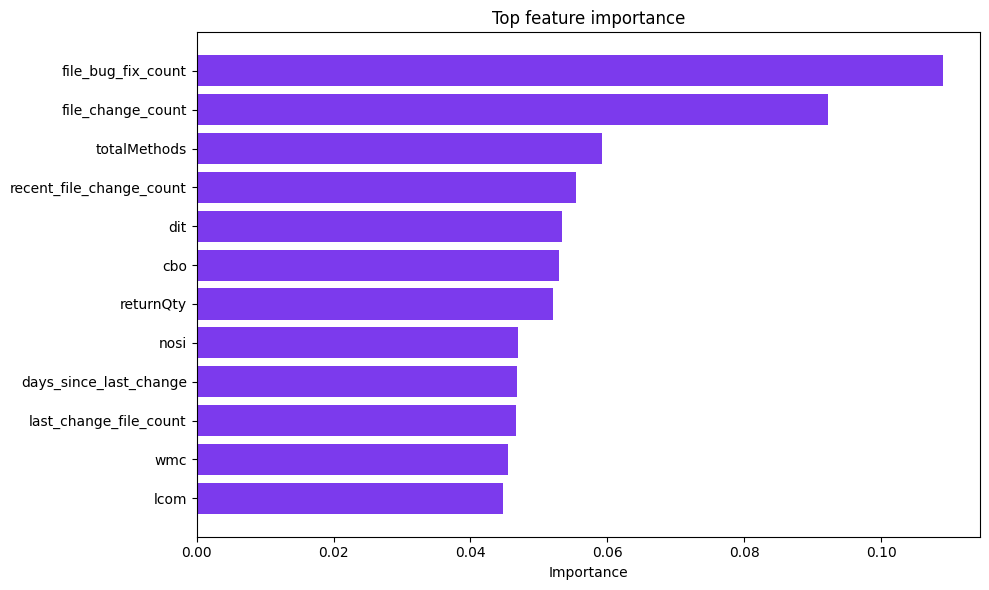

In [5]:
top = importance.head(12).copy()
value_column = "importance" if "importance" in top.columns else top.columns[-1]
feature_column = "feature" if "feature" in top.columns else top.columns[0]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top[feature_column][::-1], top[value_column][::-1], color="#7c3aed")
ax.set_title("Top feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

,predicted_non_defective,predicted_defective
actual_non_defective,159,86
actual_defective,36,279


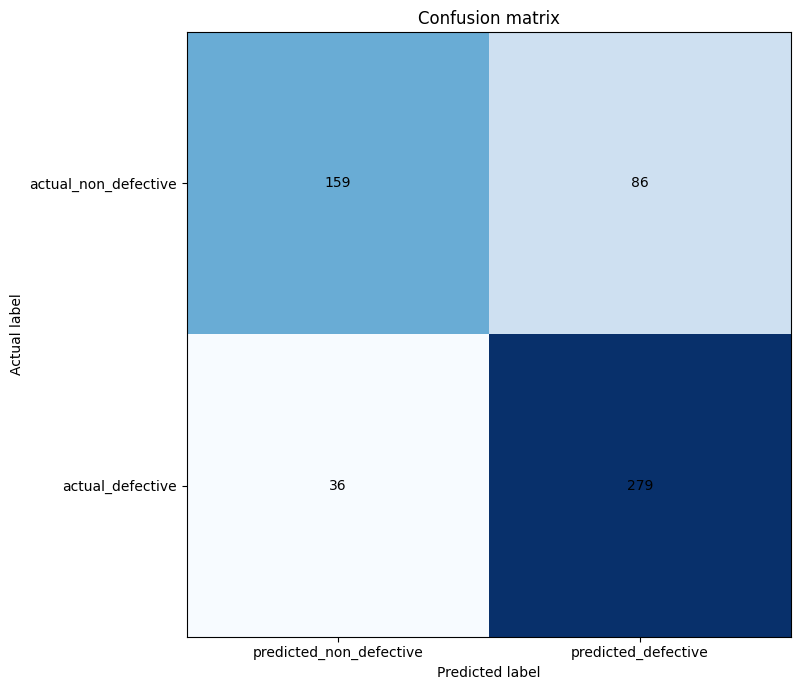

In [ ]:
matrix_path = RESULTS / "github_confusion_matrix.csv"
confusion = pd.read_csv(matrix_path, index_col=0) if matrix_path.exists() else pd.DataFrame()
display(confusion)
if not confusion.empty:
    fig, ax = plt.subplots(figsize=(10, 7))
    if sns:
        sns.heatmap(confusion, annot=True, fmt="g", cmap="Blues", ax=ax)
    else:
        ax.imshow(confusion.values, cmap="Blues")
        for row in range(confusion.shape[0]):
            for col in range(confusion.shape[1]):
                ax.text(col, row, confusion.values[row, col], ha="center", va="center")
        ax.set_xticks(range(confusion.shape[1]), confusion.columns)
        ax.set_yticks(range(confusion.shape[0]), confusion.index)
    ax.set_title("Confusion matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")
    plt.tight_layout()
    plt.show()

In [ ]:
report_path = RESULTS / "github_classification_report.txt"
print(report_path.read_text(encoding="utf-8") if report_path.exists() else "Classification report not found")